In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import HuberRegressor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.interpolate import interp1d
from scipy.optimize import minimize
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

#%mldev import

/Users/andrey/MIPT_projects/2023-project-119


In [3]:
print("Staprting Authonomy_check.ipynb ...")
#%mldev start

Staprting Authonomy_check.ipynb ...


```yaml

#%mldev nb_context

Authonomy_check:
  - import
  - start
  - experiment_mode
  - paths
  - rc
  - loss_func
  - prepare_data
  - robust_regression
  - plot_ln_ft0
  - sliding_window_setup_sgd_synthetic
  - sliding_window_setup_sgd_friedman
  - sliding_window_setup_ridgecv_synthetic
  - sliding_window_setup_ridgecv_friedman
  - sampling_update_setup_1_0_sgd_synthetic
  - sampling_update_setup_1_0_sgd_friedman
  - sampling_update_setup_1_0_ridgecv_synthetic
  - sampling_update_setup_1_0_ridgecv_friedman
  - sampling_update_setup_1_3_sgd_synthetic
  - sampling_update_setup_1_3_sgd_friedman
  - sampling_update_setup_1_3_ridgecv_synthetic
  - sampling_update_setup_1_3_ridgecv_friedman
```

In [4]:
experiment_mode = 'mldev'
#%mldev experiment_mode

In [5]:
# run this cell if you are in Jupyter and not running the notebook with mldev
experiment_mode = 'jupyter'

In [6]:
path_loop = os.getenv("MLDEV_DELTA_LOOP_PATH", default="results/hidden-loop_delta")
path_sample = os.getenv("MLDEV_DELTA_SAMPLE_PATH", default="results/hidden-sample_delta")
save_path = os.getenv("MLDEV_SAVEFIGURES_PATH", default="figures")
os.makedirs(save_path, exist_ok=True)
#%mldev paths

In [7]:
plt.rc('axes', titlesize=25, titleweight='bold') #fontsize of the title
plt.rc('axes', labelsize=20) #fontsize of the x and y labels
plt.rc('xtick', labelsize=20) #fontsize of the x tick labels
plt.rc('ytick', labelsize=20) #fontsize of the y tick labels
plt.rc('legend', fontsize=25) #fontsize of the legend
plt.rc('figure', figsize=(12, 8)) # figure size
#%mldev rc

In [8]:
# Robust loss function
def huber_loss_func(X, y, w, sigma, alpha=0.05, eps=1.35):
    def H_eps(z):
        if np.abs(z) < eps:
            return z**2
        else:
            return 2 * eps * np.abs(z) - eps**2

    Sum = 0. 
    for x_i, y_i in zip(X, y):
        Sum += sigma + H_eps((x_i * w[0] + w[1] - y_i) / sigma) * sigma
    return Sum + alpha * (w[0]**2 + w[1]**2)
#%mldev loss_func

In [9]:
def prepare_data(path, usage=1, adherence=0, run_times=10, dataset_name='syntetic',
                 model_name='sgd_model_50', t_end=None):
    directory = Path(f"{path}/{adherence}-{usage}/{dataset_name}/{model_name}/0")
    steps = []
    for file in directory.iterdir():
        if file.name != '.DS_Store':
            steps.append(int(file.name.split('_')[-1].split('.')[0]))
    steps = sorted(steps)
    if t_end is not None:
        steps = steps[:t_end]
    f_t0_list = []
    loss_list = []
    
    for trial in range(run_times):
        for step in steps:
            directory = Path(f"{path}/{adherence}-{usage}/{dataset_name}/{model_name}/{trial}")
            data = pd.read_csv(f"{directory}/dev_step_{step}.csv")
            data_hist = data['y'] - data['y_pred']
            hst = np.histogram(data_hist, density=True, bins=200)
            f_t = interp1d(hst[1][:-1], hst[0], kind='linear',
                           fill_value=0.0, bounds_error=False)
            f_t0_list.append(max(float(f_t(0.)), 1e-5))
            loss_list.append(np.linalg.norm(data_hist)**2)

    return f_t0_list, steps, loss_list
#%mldev prepare_data

In [10]:
def robust_regression(steps_inter, logs, t_inters):
    num_parts = len(t_inters) - 1
    def function(x):
        ks = x[:num_parts]
        bs = x[num_parts:2*num_parts]
        sigma = x[-1]
        
        loss = 0
        for k, b, step, log in zip(ks, bs, steps_inter, logs):
            #loss += np.linalg.norm(k * step + b - log)**2
            loss += huber_loss_func(step, log, (k, b), sigma)
        return loss
        
    constr = [{'type' : 'ineq', 'fun' : lambda x : x[-1] - 1}]
    if num_parts >= 2:
        const = {'type' : 'eq', 
                    'fun' : lambda x : (x[0] - x[1]) * t_inters[1] + x[num_parts] - x[num_parts+1]}
        constr.append(const)
    if num_parts >= 3:
        const = {'type' : 'eq', 
                    'fun' : lambda x : (x[1] - x[2]) * t_inters[2] + x[num_parts+1] - x[num_parts+2]}
        constr.append(const)
    if num_parts >= 4:
        const = {'type' : 'eq', 
                    'fun' : lambda x : (x[2] - x[3]) * t_inters[3] + x[num_parts+2] - x[num_parts+3]}
        constr.append(const)
    
    start_point = [0] * 2 * num_parts + [1]
    res = minimize(function, start_point, constraints=constr, tol=0.001)
    ks = res.x[:num_parts]
    bs = res.x[num_parts:2*num_parts]

    return ks, bs
#%mldev robust_regression

In [26]:
def plot_ln_ft0(f_t0_list, steps, t_inters, linear_segments, run_times=10, tol=None,
                usage=1.0, adherence=0.0, experiment_name='sliding_window', 
                model_name='sgd_model_50', dataset_name='syntetic', 
                experiment_mode='jupyter'):
    plt.title(f"usage={usage}, adherence={adherence}")
    plt.xlabel(r"step $t$")
    plt.ylabel(r"$\ln(f_t(0))$")
    steps_big = np.array(steps * run_times)
    t_inters = [0] + t_inters + [steps[-1]+1]
    logs = []
    steps_inter = []
    for i in range(len(t_inters) - 1):
        idxs = (t_inters[i] <= steps_big) & (steps_big < t_inters[i+1])
        logs.append(np.log(f_t0_list)[idxs])
        steps_inter.append(steps_big[idxs])
    colors_log = ['blue', 'green', 'orange', 'purple', 'black']
    for i, (step, log, color_log) in enumerate(zip(steps_inter, logs, colors_log)):
        label = r"$\ln(f_t(0))$" + f", part {i+1}"
        sns.lineplot(x=step, y=log, color=color_log, marker=None, label=label)

    steps_inter_lin = [] # убираем нелинейную часть
    logs_lin = []
    t_inters_lin = []
    for segment in linear_segments:
        steps_inter_lin.append(steps_inter[segment])
        logs_lin.append(logs[segment])
        t_inters_lin.append(t_inters[segment])
    steps_inter = steps_inter_lin
    logs = logs_lin
    t_inters = t_inters_lin + [t_inters[-1]]
    
    ks, bs = robust_regression(steps_inter, logs, t_inters)
    #print(ks, bs)

    linear_log = []
    for k, b, step in zip(ks, bs, steps_inter):
        linear_log.append(k * step + b)
    true_log = np.hstack(logs)
    linear_log = np.hstack(linear_log)
    steps_stack = np.hstack(steps_inter)

    if len(ks) > 1:
        label = 'piecewise linear approximation'
    else:
        label = 'linear approximation'
    
    r2score = r2_score(true_log, linear_log)
    plt.plot(steps_stack, linear_log, '-', color='red',
                label=f"{label}\nr2 score = {r2score:.3f}")

    # test for heteroscedasticity
    if tol is not None:
        err = (linear_log - true_log)**2
        residuals = (true_log - linear_log)[err <= tol]
        x = steps_stack[err <= tol]
    else:
        residuals = (true_log - linear_log)
        x = steps_stack

    _, p_val, _, _ = het_breuschpagan(residuals, list(zip(np.ones_like(x), x)))

    print(f'{experiment_name}, dataset={dataset_name}, model_name={model_name},', end=' ')
    print(f'usage={usage}, adherence={adherence}:')
    print(f'p_value = {p_val:.3f}, homoscedasticity: {p_val < 0.05}')
    
    plt.legend()
    plt.grid()
    plt.tight_layout()
    if experiment_mode == 'jupyter':
        plt.show()
    elif experiment_mode == 'mldev':
        plt.savefig(f"{save_path}/aut_{experiment_name}_{dataset_name}_{model_name}_{usage}_{adherence}.png")
        plt.close()
    else:
        raise ValueError(f"Wrong experiment mode {experiment_mode}!")
#%mldev plot_ln_ft0

## Sliding window setup

sw, dataset=synthetic, model_name=sgd_model_50, usage=1.0, adherence=0.0:
p_value = 0.001, homoscedasticity: True


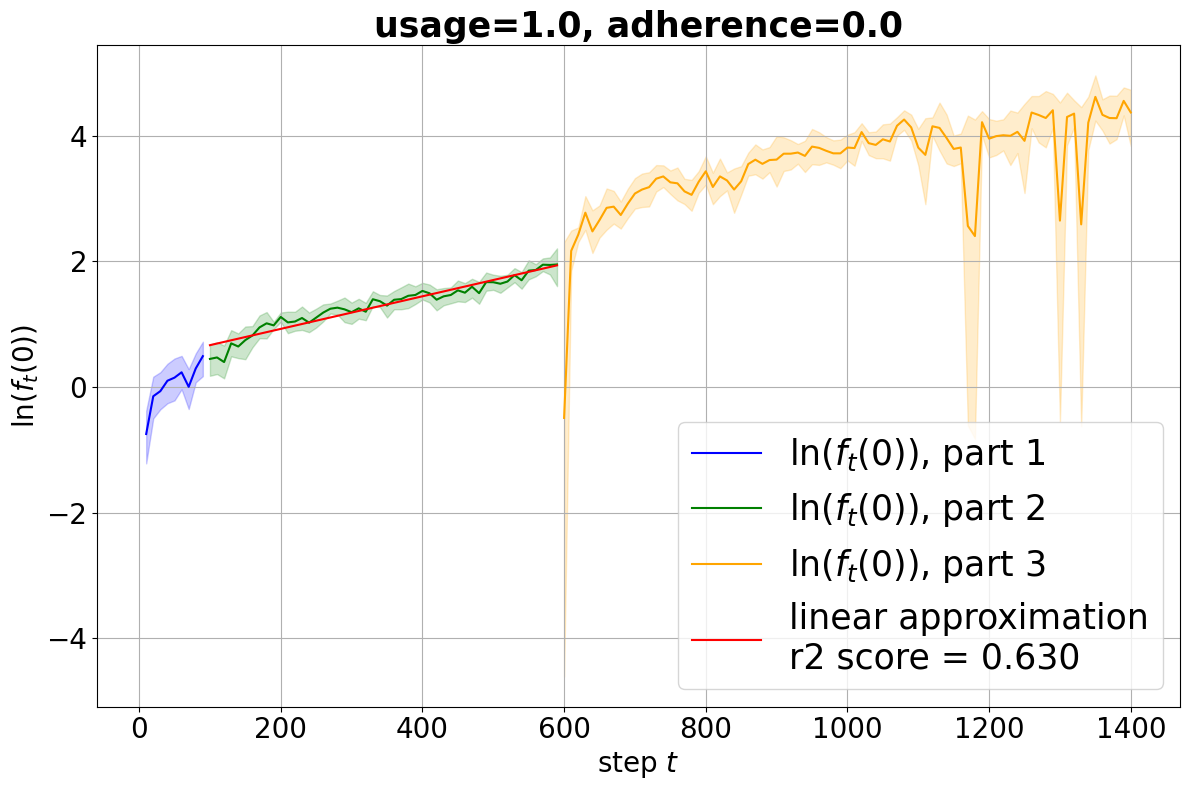

In [12]:
model_name = 'sgd_model_50'
dataset_name = 'synthetic'
f_t0_list, steps, _ = prepare_data(path=path_loop, usage=1.0, adherence=0.0, run_times=10,
                                   model_name=model_name, dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[100., 600.], linear_segments=[1],
            tol=None, steps=steps, usage=1.0, adherence=0.0, run_times=10,
            model_name=model_name, experiment_name='sw', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sliding_window_setup_sgd_synthetic

sw, dataset=friedman, model_name=sgd_model_50, usage=1.0, adherence=0.0:
p_value = 0.000, homoscedasticity: True


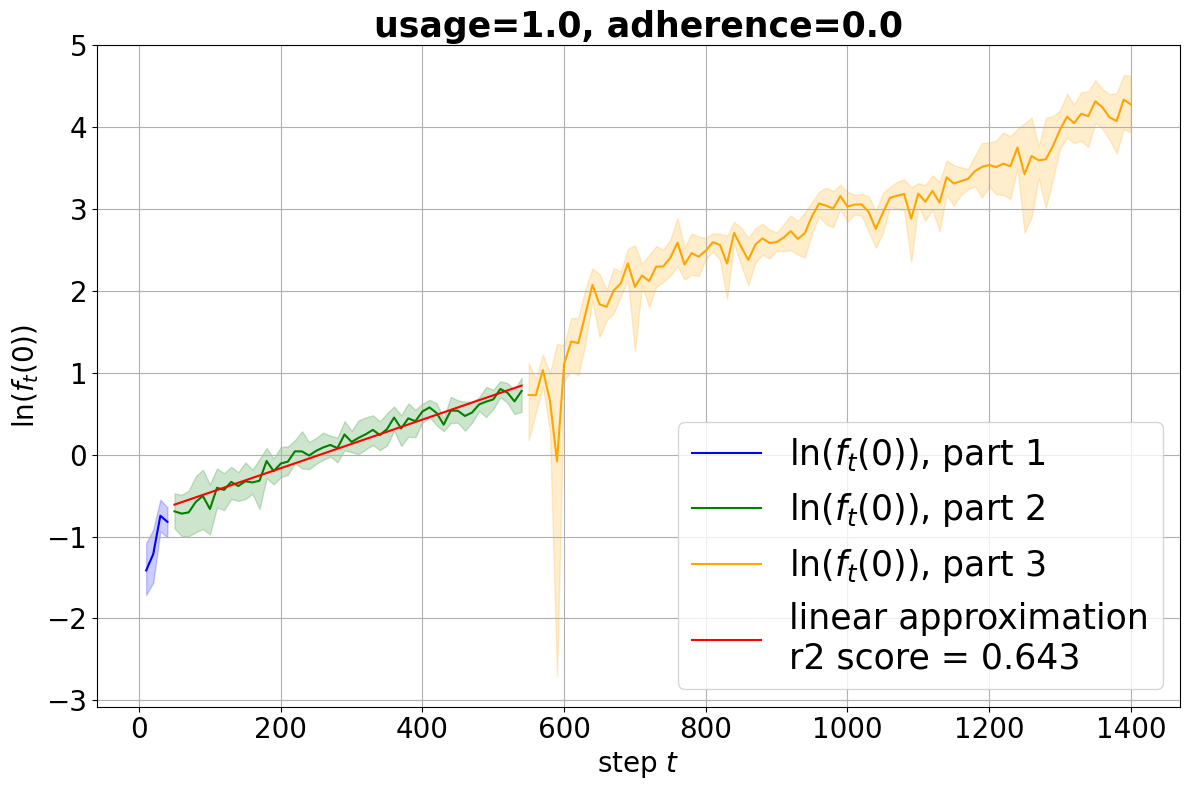

In [14]:
model_name = 'sgd_model_50'
dataset_name = 'friedman'
f_t0_list, steps, _ = prepare_data(path=path_loop, usage=1.0, adherence=0.0, run_times=10,
                                   model_name=model_name, dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[50., 550.], linear_segments=[1],
            tol=None, steps=steps, usage=1.0, adherence=0.0, run_times=10,
            model_name=model_name, experiment_name='sw', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sliding_window_setup_sgd_friedman

sw, dataset=synthetic, model_name=ridgecv_model, usage=1.0, adherence=0.0:
p_value = 0.002, homoscedasticity: True


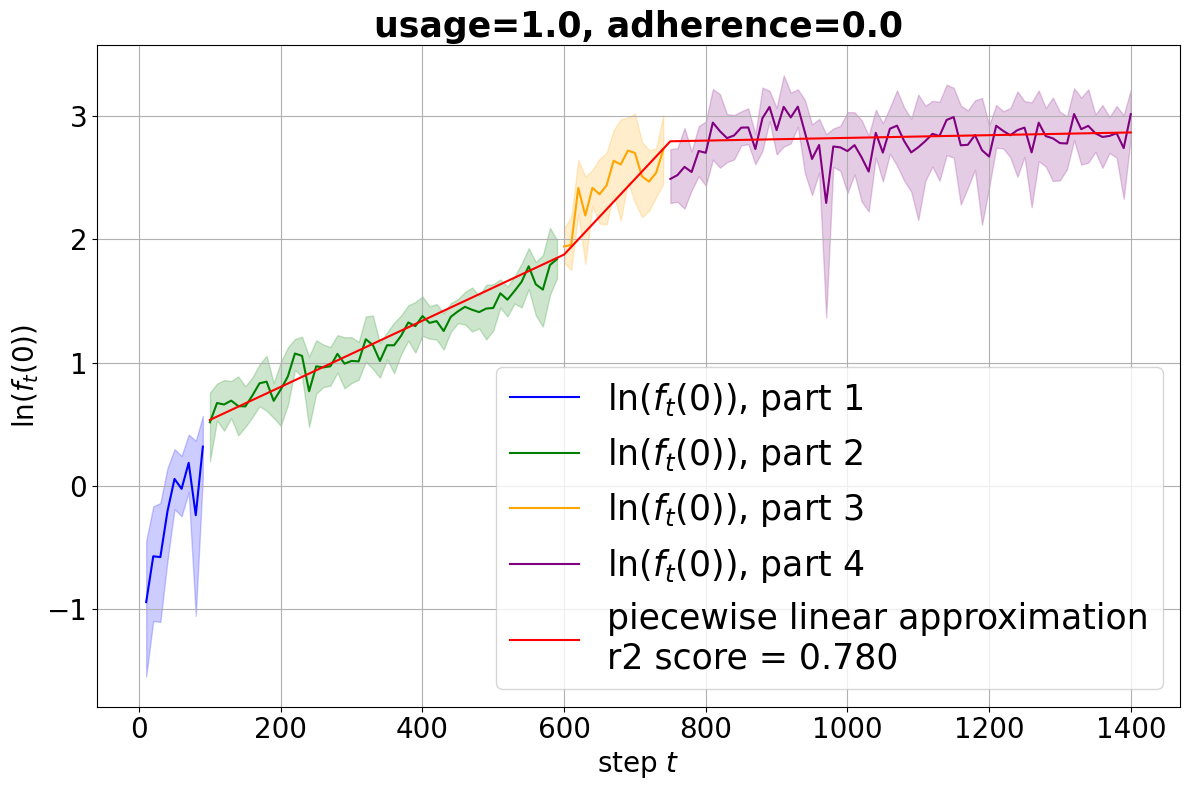

In [15]:
model_name = 'ridgecv_model'
dataset_name = 'synthetic'
f_t0_list, steps, _ = prepare_data(path=path_loop, usage=1.0, adherence=0.0, run_times=10,
                                   model_name=model_name, dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[100., 600., 750.],
            linear_segments=[1, 2, 3],
            tol=None, steps=steps, usage=1.0, adherence=0.0, run_times=10,
            model_name=model_name, dataset_name=dataset_name,
            experiment_name='sw', experiment_mode=experiment_mode)
#%mldev sliding_window_setup_ridgecv_synthetic

sw, dataset=friedman, model_name=ridgecv_model, usage=1.0, adherence=0.0:
p_value = 0.000, homoscedasticity: True


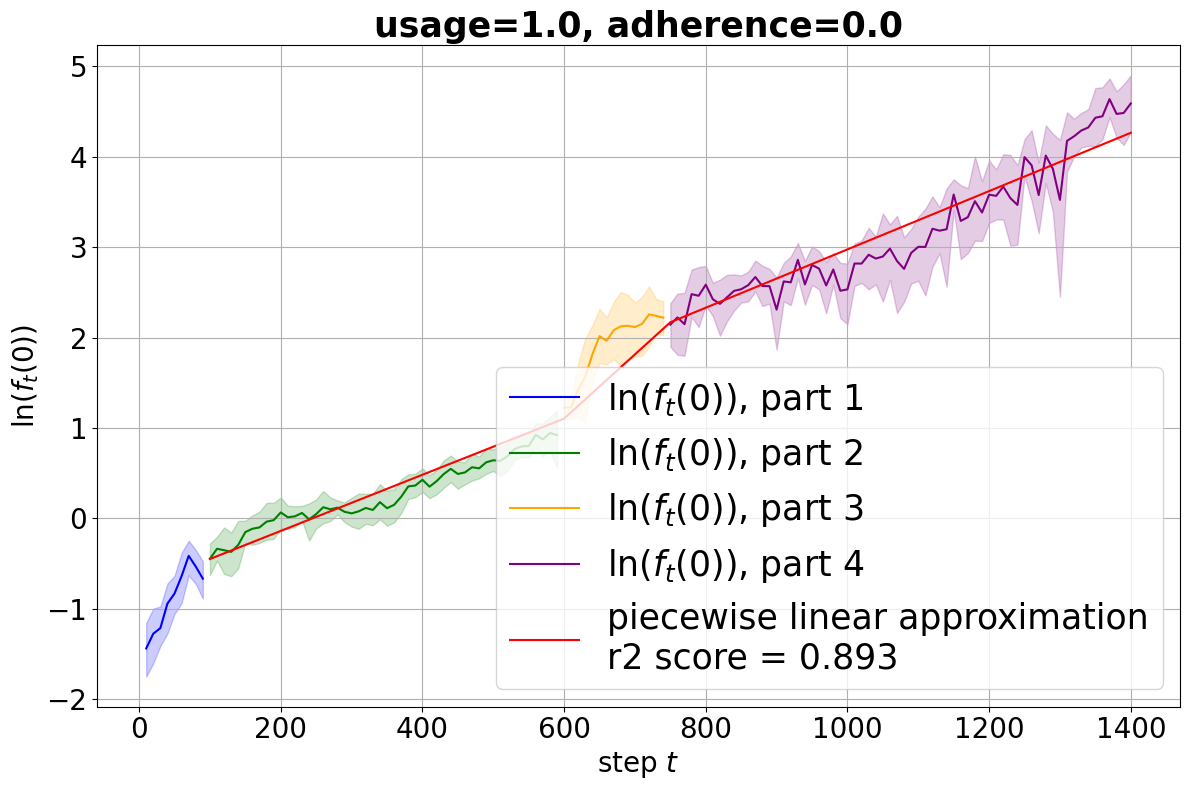

In [16]:
model_name = 'ridgecv_model'
dataset_name = 'friedman'
f_t0_list, steps, _ = prepare_data(path=path_loop, usage=1.0, adherence=0.0, run_times=10,
                                   model_name=model_name, dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[100., 600., 750.],
            linear_segments=[1, 2, 3],
            tol=None, steps=steps, usage=1.0, adherence=0.0, run_times=10,
            model_name=model_name, dataset_name=dataset_name,
            experiment_name='sw', experiment_mode=experiment_mode)
#%mldev sliding_window_setup_ridgecv_friedman

## Sampling update setup. usage=1, adherence=0

su, dataset=synthetic, model_name=sgd_model_50, usage=1.0, adherence=0.0:
p_value = 0.000, homoscedasticity: True


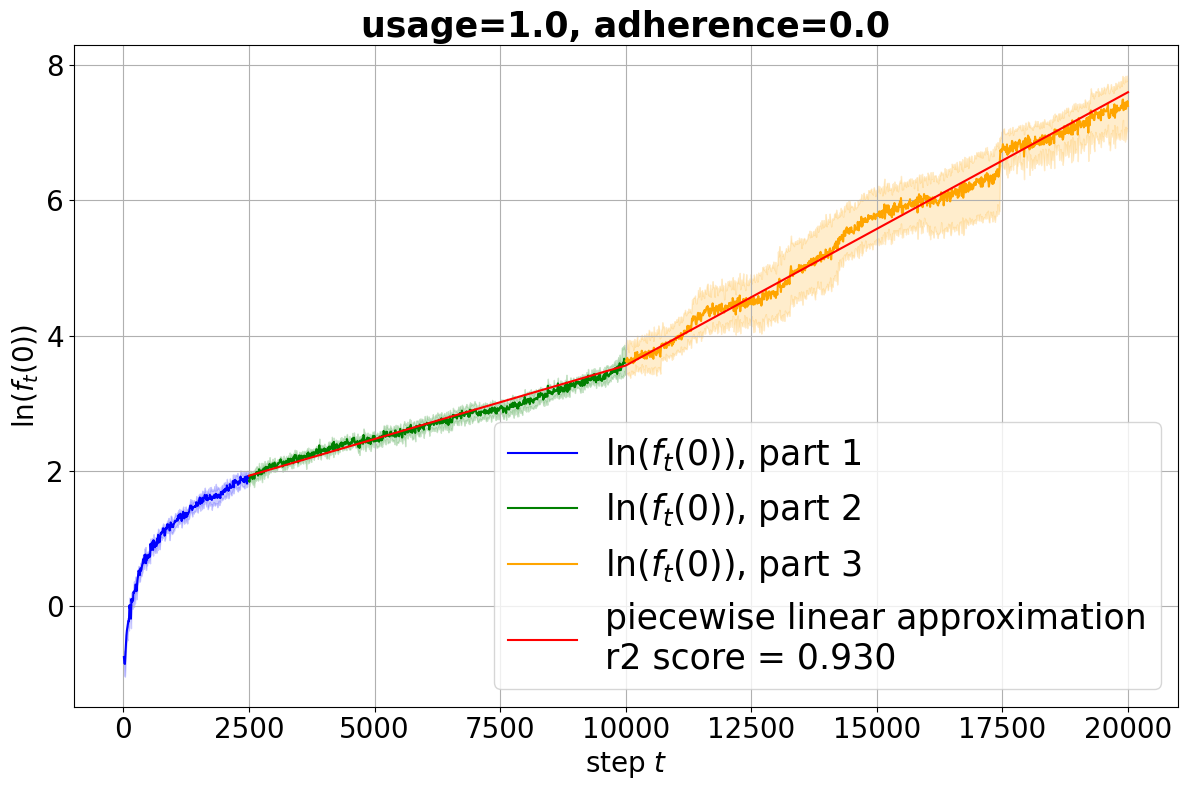

In [17]:
model_name = 'sgd_model_50'
dataset_name = 'synthetic'
f_t0_list, steps, _ = prepare_data(path=path_sample, usage=1.0, adherence=0.0, run_times=10,
                                   model_name=model_name, t_end=2000,
                                   dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[2500., 10000.], linear_segments=[1, 2],
            tol=None, steps=steps, usage=1.0, adherence=0.0, run_times=10,
            model_name=model_name, experiment_name='su', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sampling_update_setup_1_0_sgd_synthetic

su, dataset=friedman, model_name=sgd_model_50, usage=1.0, adherence=0.0:
p_value = 0.000, homoscedasticity: True


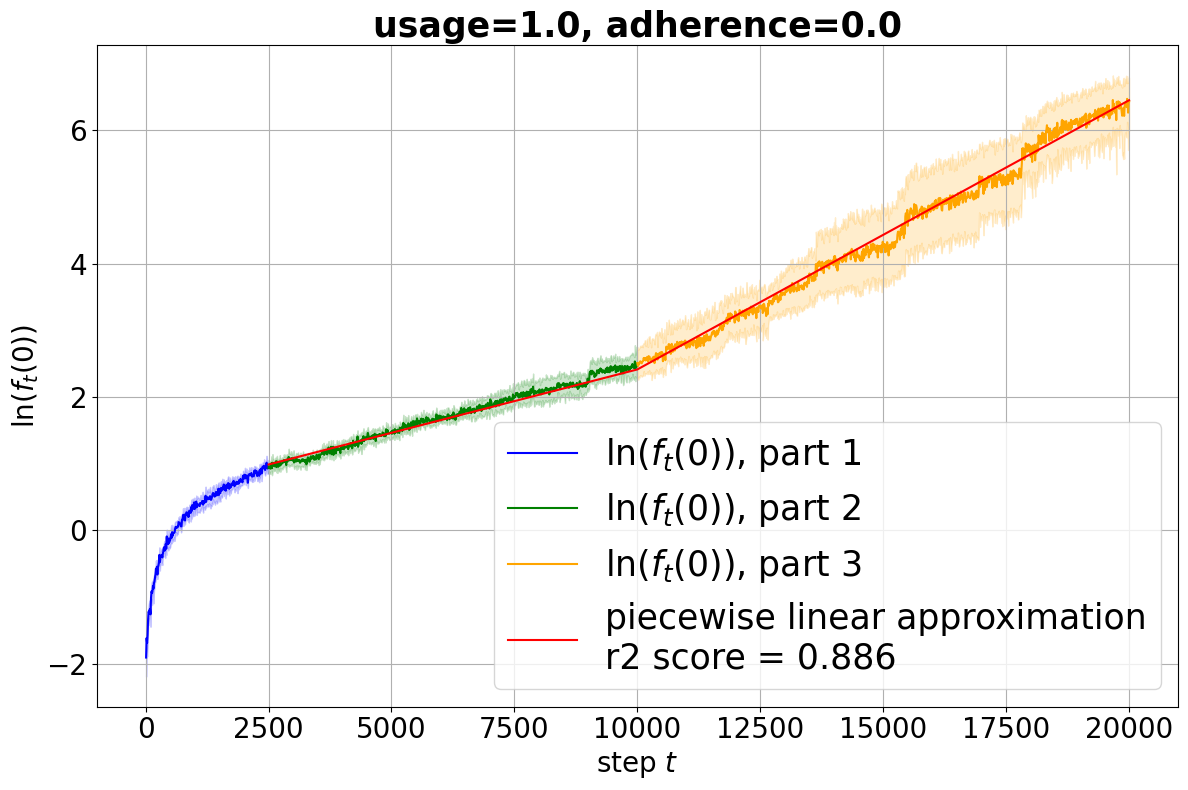

In [18]:
model_name = 'sgd_model_50'
dataset_name = 'friedman'
f_t0_list, steps, _ = prepare_data(path=path_sample, usage=1.0, adherence=0.0, run_times=10,
                                   model_name=model_name, t_end=2000,
                                   dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[2500., 10000.], linear_segments=[1, 2],
            tol=None, steps=steps, usage=1.0, adherence=0.0, run_times=10,
            model_name=model_name, experiment_name='su', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sampling_update_setup_1_0_sgd_friedman

su, dataset=synthetic, model_name=ridgecv_model, usage=1.0, adherence=0.0:
p_value = 0.000, homoscedasticity: True


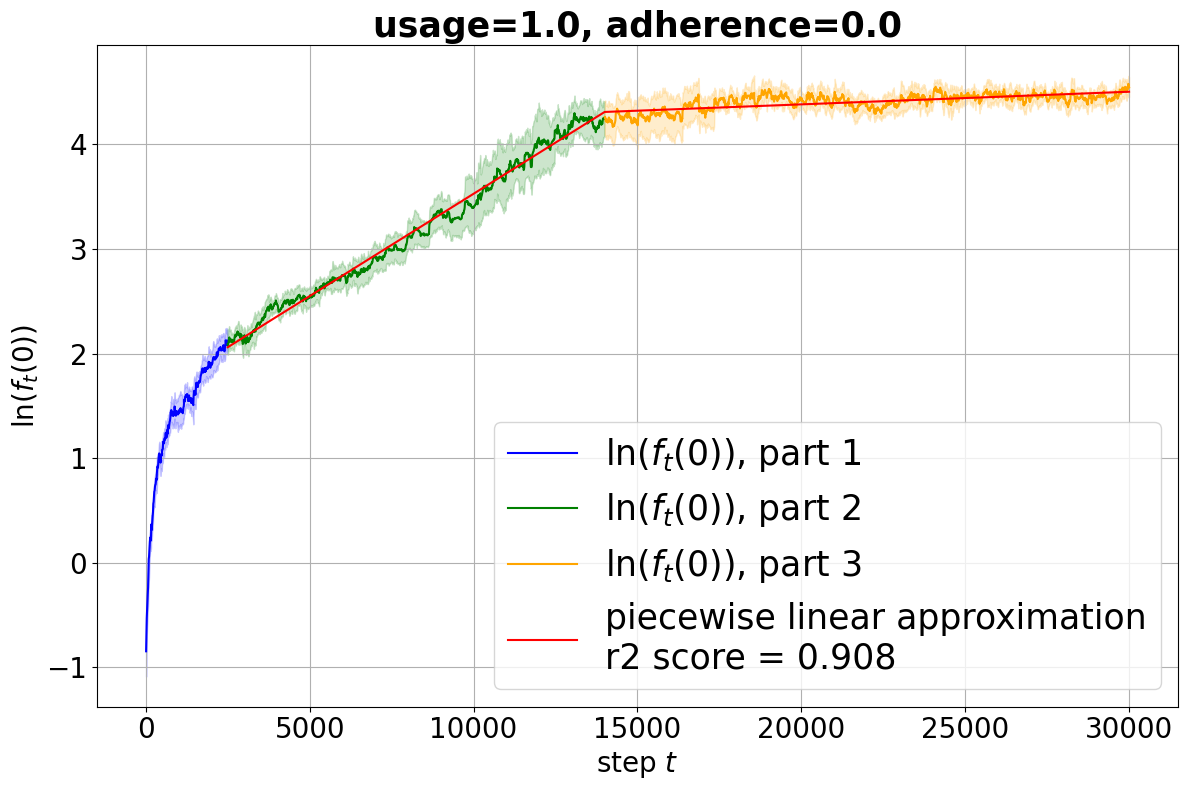

In [32]:
model_name = 'ridgecv_model'
dataset_name = 'synthetic'
f_t0_list, steps, _ = prepare_data(path=path_sample, usage=1.0, adherence=0.0, run_times=10,
                                   model_name=model_name, t_end=3000,
                                   dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[2500., 14000.], 
            linear_segments=[1, 2],
            tol=None, steps=steps, usage=1.0, adherence=0.0, run_times=10,
            model_name=model_name, experiment_name='su', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sampling_update_setup_1_0_ridgecv_synthetic

su, dataset=friedman, model_name=ridgecv_model, usage=1.0, adherence=0.0:
p_value = 0.000, homoscedasticity: True


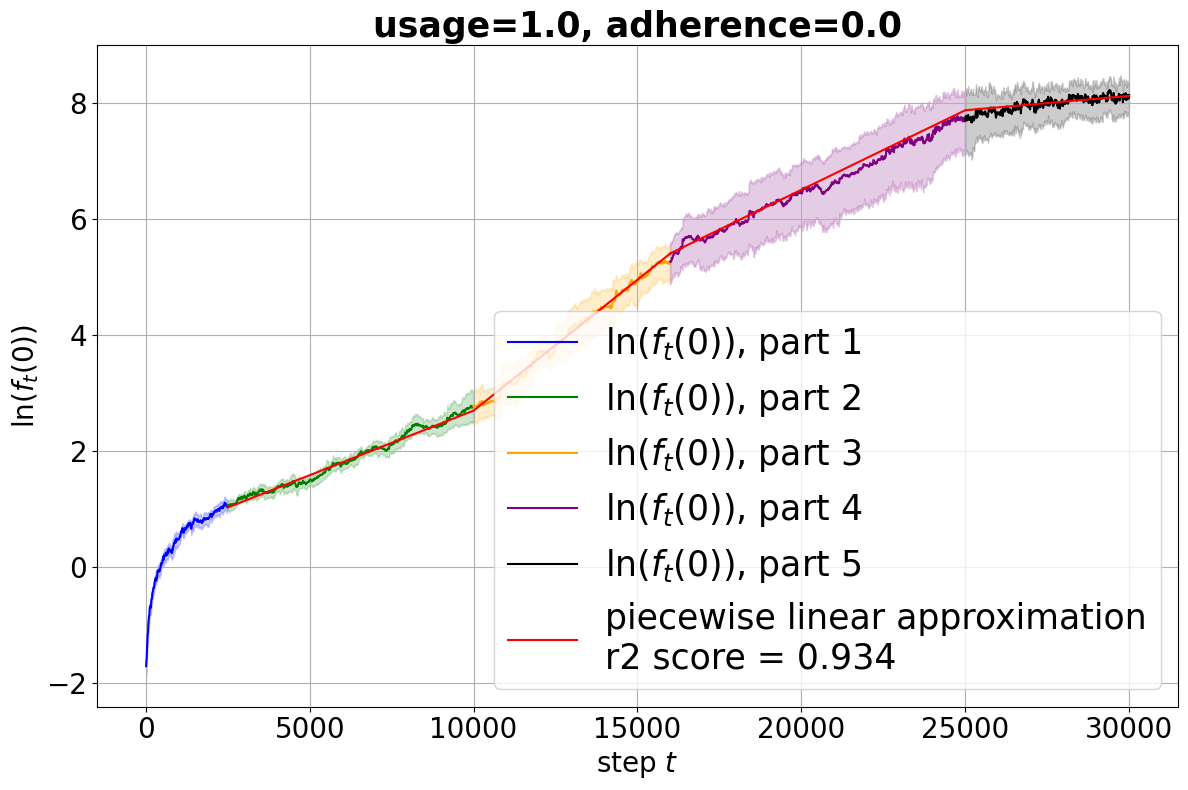

In [27]:
model_name = 'ridgecv_model'
dataset_name = 'friedman'
f_t0_list, steps, _ = prepare_data(path=path_sample, usage=1.0, adherence=0.0, run_times=10,
                                   model_name=model_name, t_end=3000,
                                   dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[2500., 10000., 16000., 25000.], 
            linear_segments=[1, 2, 3, 4],
            tol=None, steps=steps, usage=1.0, adherence=0.0, run_times=10,
            model_name=model_name, experiment_name='su', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sampling_update_setup_1_0_ridgecv_friedman

## Sampling update setup. usage=1, adherence=3

su, dataset=synthetic, model_name=sgd_model_50, usage=1.0, adherence=3.0:
p_value = 0.000, homoscedasticity: True


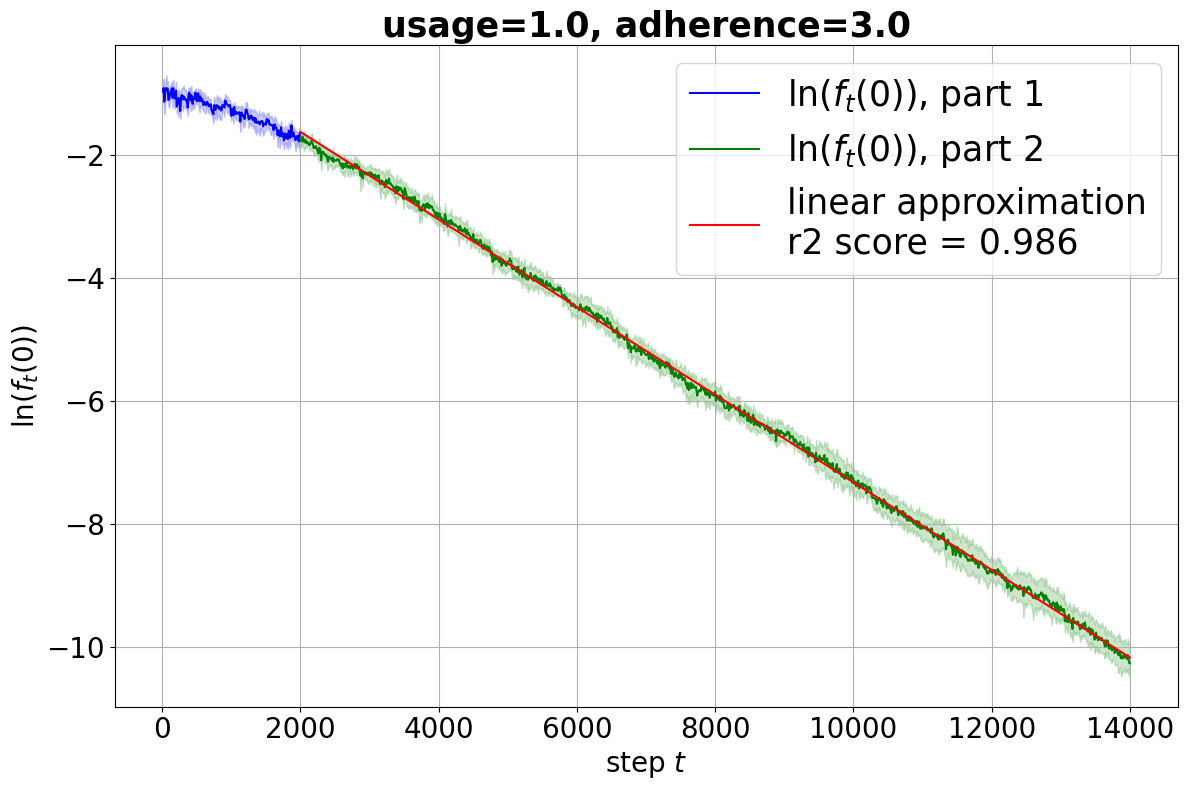

In [28]:
model_name = 'sgd_model_50'
dataset_name = 'synthetic'
f_t0_list, steps, _ = prepare_data(path=path_sample, usage=1.0, adherence=3.0, run_times=10,
                                   model_name=model_name, t_end=1400,
                                   dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[2000], linear_segments=[1],
            tol=None, steps=steps, usage=1.0, adherence=3.0, run_times=10,
            model_name=model_name, experiment_name='su', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sampling_update_setup_1_3_sgd_synthetic

su, dataset=friedman, model_name=sgd_model_50, usage=1.0, adherence=3.0:
p_value = 0.000, homoscedasticity: True


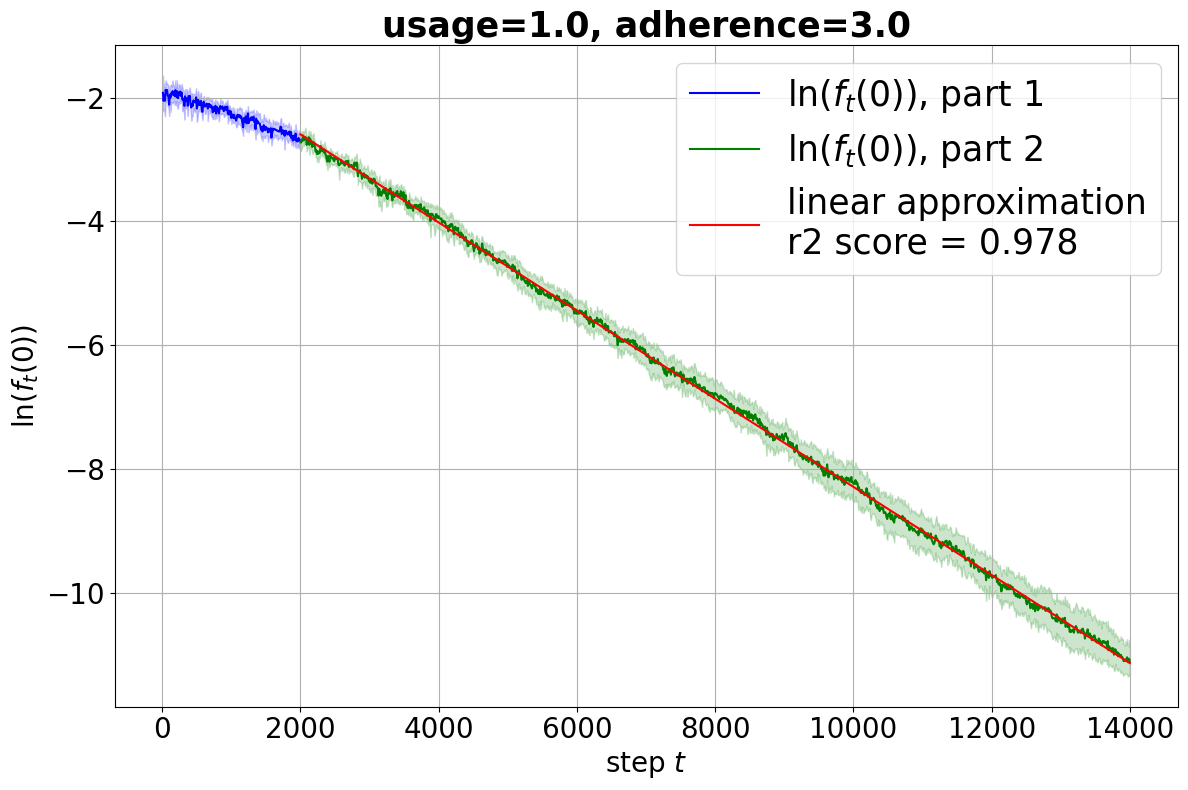

In [29]:
model_name = 'sgd_model_50'
dataset_name = 'friedman'
f_t0_list, steps, _ = prepare_data(path=path_sample, usage=1.0, adherence=3.0, run_times=10,
                                   model_name=model_name, t_end=1400,
                                   dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[2000], linear_segments=[1],
            tol=None, steps=steps, usage=1.0, adherence=3.0, run_times=10,
            model_name=model_name, experiment_name='su', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sampling_update_setup_1_3_sgd_friedman

su, dataset=synthetic, model_name=ridgecv_model, usage=1.0, adherence=3.0:
p_value = 0.000, homoscedasticity: True


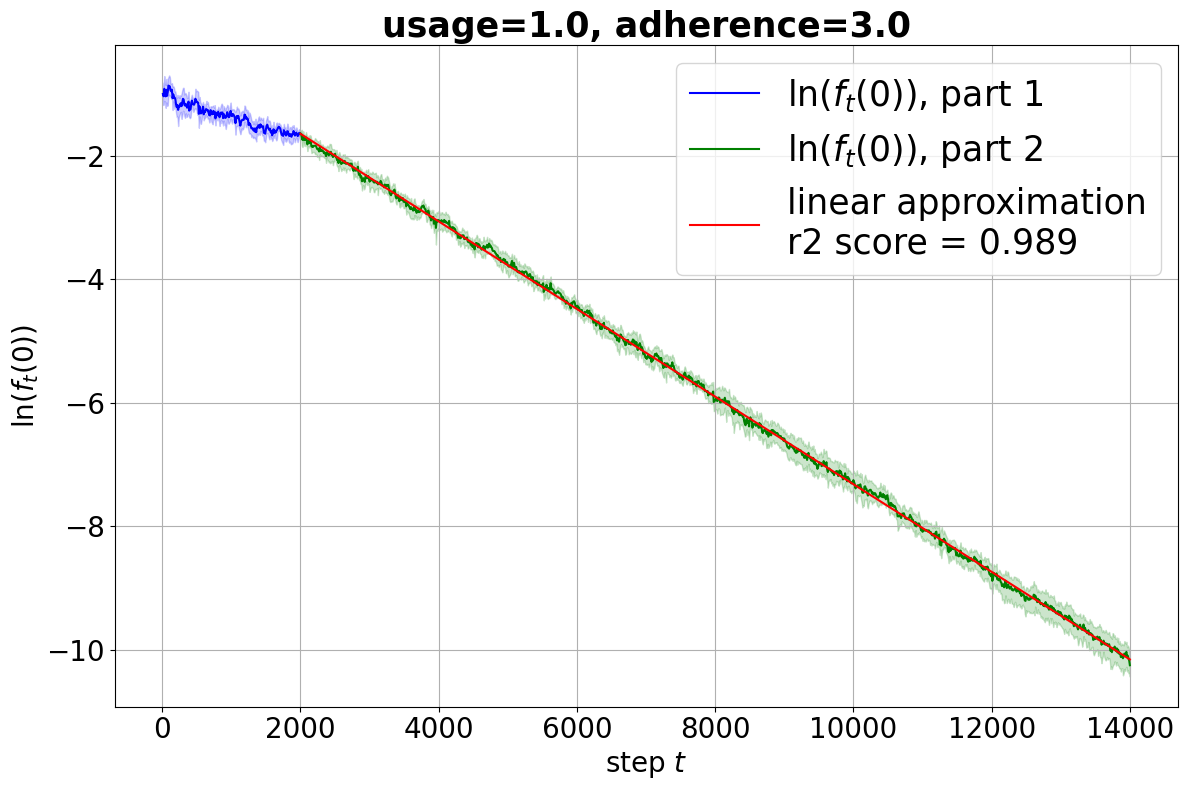

In [30]:
model_name = 'ridgecv_model'
dataset_name = 'synthetic'
f_t0_list, steps, _ = prepare_data(path=path_sample, usage=1.0, adherence=3.0, run_times=10,
                                   model_name=model_name, t_end=1400,
                                   dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[2000], linear_segments=[1],
            tol=None, steps=steps, usage=1.0, adherence=3.0, run_times=10,
            model_name=model_name, experiment_name='su', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sampling_update_setup_1_3_ridgecv_synthetic

su, dataset=friedman, model_name=ridgecv_model, usage=1.0, adherence=3.0:
p_value = 0.000, homoscedasticity: True


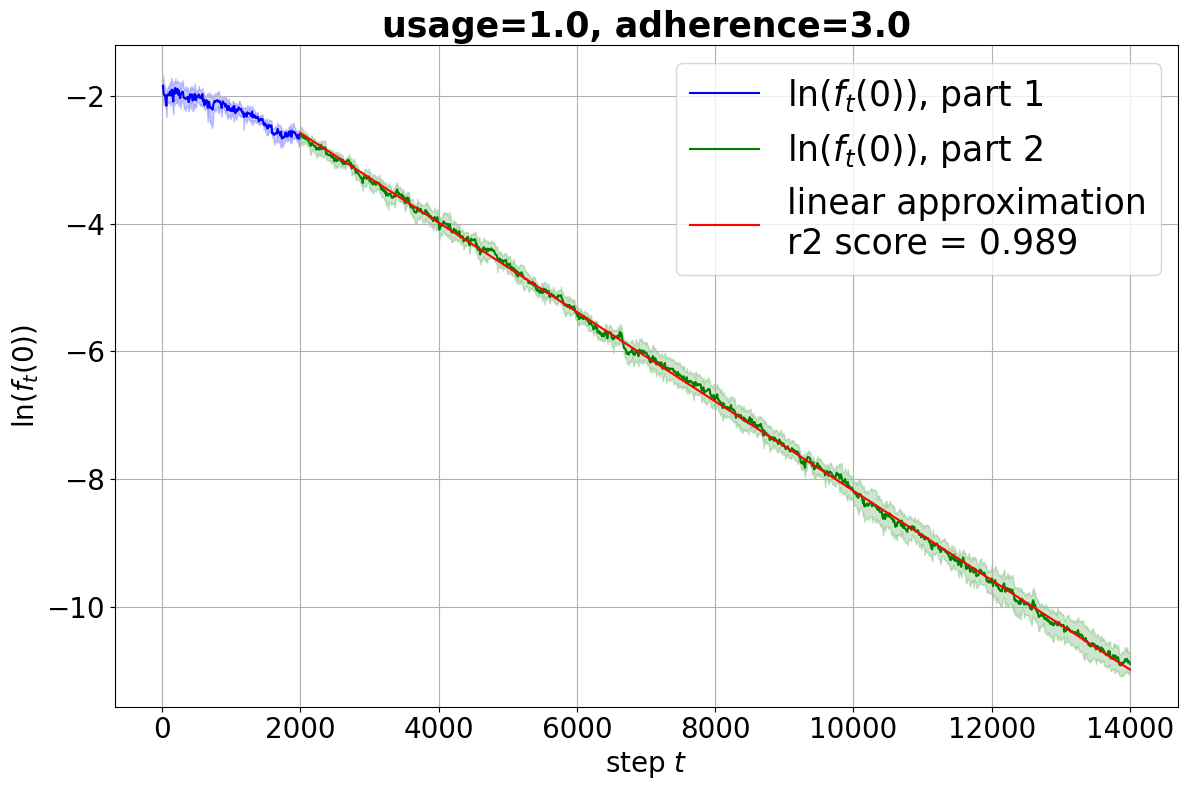

In [31]:
model_name = 'ridgecv_model'
dataset_name = 'friedman'
f_t0_list, steps, _ = prepare_data(path=path_sample, usage=1.0, adherence=3.0, run_times=10,
                                   model_name=model_name, t_end=1400,
                                   dataset_name=dataset_name)

plot_ln_ft0(f_t0_list=f_t0_list, t_inters=[2000], linear_segments=[1],
            tol=None, steps=steps, usage=1.0, adherence=3.0, run_times=10,
            model_name=model_name, experiment_name='su', dataset_name=dataset_name,
            experiment_mode=experiment_mode)
#%mldev sampling_update_setup_1_3_ridgecv_friedman